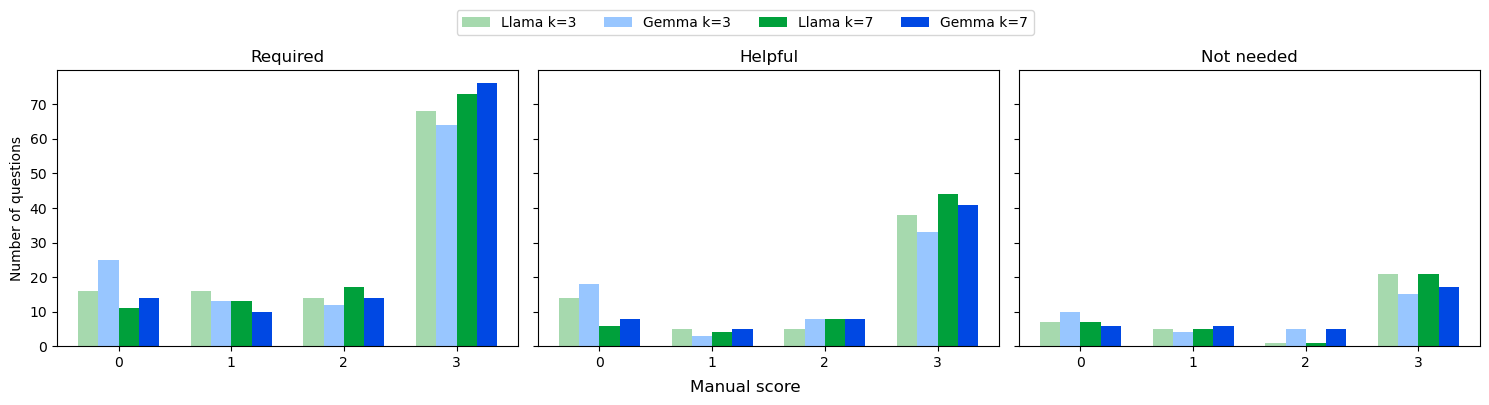

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------
# LOAD CSVs
# ----------------------------

initial = pd.read_csv("../evaluation/eval_sheet.csv")
tuned = pd.read_csv("../evaluation/eval_sheet_tuned.csv")

# ----------------------------
# NORMALIZE RETRIEVAL LABELS
# ----------------------------

def normalize(x):
    x = str(x).strip().lower()

    if "require" in x:
        return "required"

    if "help" in x:
        return "helpful"

    return "not needed"

initial["Retrieval Needed"] = initial["Retrieval Needed"].apply(normalize)
tuned["Retrieval Needed"] = tuned["Retrieval Needed"].apply(normalize)

# ----------------------------
# CONFIG
# ----------------------------

categories = ["required", "helpful", "not needed"]
scores = [0, 1, 2, 3]

systems = {
    "Llama k=3": (
        initial,
        "Llama — Score (3/2/1/0)"
    ),
    "Gemma k=3": (
        initial,
        "Gemma — Score (3/2/1/0)"
    ),
    "Llama k=7": (
        tuned,
        "Llama — Score (3/2/1/0)"
    ),
    "Gemma k=7": (
        tuned,
        "Gemma — Score (3/2/1/0)"
    ),
}

colors = {
    "Llama k=3": "#A6D9AE",
    "Llama k=7": "#00A03B",
    "Gemma k=3": "#98C6FF",
    "Gemma k=7": "#0048E3",
}

# ----------------------------
# PLOT
# ----------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 4),
    sharey=True
)

bar_width = 0.18

for ax, category in zip(axes, categories):

    x = np.arange(len(scores))

    for i, (name, (df, score_col)) in enumerate(systems.items()):

        subset = df[df["Retrieval Needed"] == category]

        counts = []

        for s in scores:
            cnt = (pd.to_numeric(
                subset[score_col],
                errors="coerce"
            ) == s).sum()

            counts.append(cnt)

        offset = (i - 1.5) * bar_width

        ax.bar(
            x + offset,
            counts,
            width=bar_width,
            label=name,
            color=colors[name]
        )

    ax.set_title(category.capitalize())
    ax.set_xticks(x)
    ax.set_xticklabels(scores)

axes[0].set_ylabel("Number of questions")
fig.supxlabel("Manual score", y=0.1)

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=4,
    bbox_to_anchor=(0.5, 1.08)
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig("../evaluation/score_breakdown_by_retrieval.png", dpi=300, bbox_inches="tight")
plt.show()

In [4]:
import os
os.getcwd()

'/Users/sibi/Projects/FRI/Natural Language Processing/ul-fri-nlp-course-project-2025-2026-hungover_pandas/code'

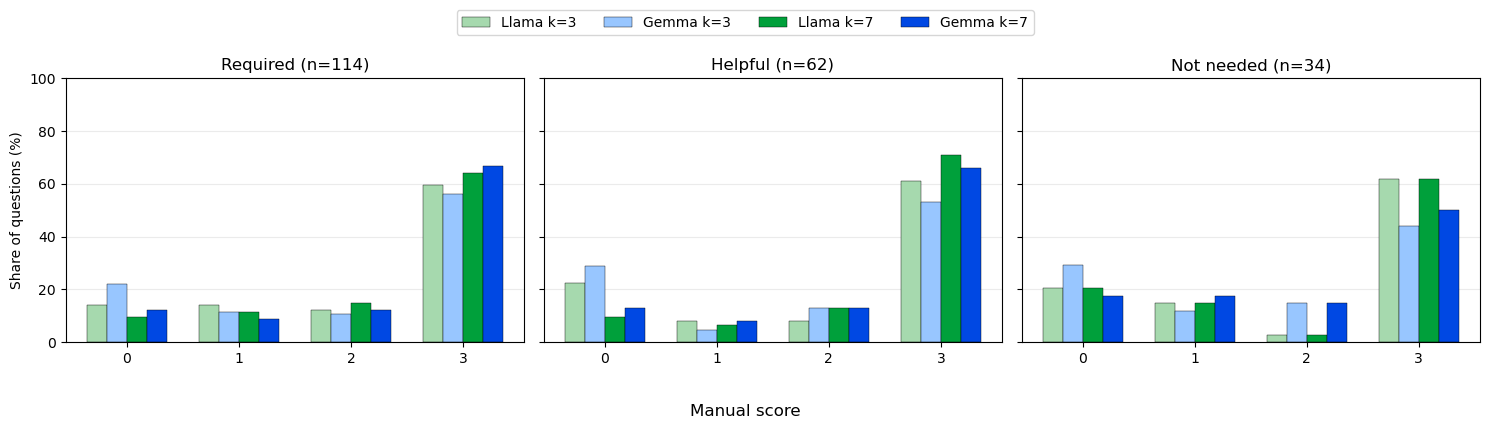

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------
# LOAD CSVs
# ----------------------------

initial = pd.read_csv("../evaluation/eval_sheet.csv")
tuned = pd.read_csv("../evaluation/eval_sheet_tuned.csv")

# ----------------------------
# NORMALIZE RETRIEVAL LABELS
# ----------------------------

def normalize(x):
    x = str(x).strip().lower()

    if "require" in x:
        return "required"
    if "help" in x:
        return "helpful"
    if "not" in x:
        return "not needed"

    return "not needed"


initial["Retrieval Needed"] = initial["Retrieval Needed"].apply(normalize)
tuned["Retrieval Needed"] = tuned["Retrieval Needed"].apply(normalize)

# ----------------------------
# CONFIG
# ----------------------------

categories = ["required", "helpful", "not needed"]
scores = [0, 1, 2, 3]

systems = {
    "Llama k=3": (initial, "Llama — Score (3/2/1/0)"),
    "Gemma k=3": (initial, "Gemma — Score (3/2/1/0)"),
    "Llama k=7": (tuned, "Llama — Score (3/2/1/0)"),
    "Gemma k=7": (tuned, "Gemma — Score (3/2/1/0)"),
}

colors = {
    "Llama k=3": "#A6D9AE",
    "Llama k=7": "#00A03B",
    "Gemma k=3": "#98C6FF",
    "Gemma k=7": "#0048E3",
}

# ----------------------------
# PREPARE COUNTS
# ----------------------------

score_tables = {}

for category in categories:
    score_tables[category] = {}

    for name, (df, score_col) in systems.items():
        subset = df[df["Retrieval Needed"] == category]
        score_series = pd.to_numeric(subset[score_col], errors="coerce")

        total = len(score_series.dropna())

        counts = [(score_series == s).sum() for s in scores]
        percentages = [
            (count / total * 100) if total > 0 else 0
            for count in counts
        ]

        score_tables[category][name] = {
            "counts": counts,
            "percentages": percentages,
            "total": total,
        }

# ----------------------------
# PLOT
# ----------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 4),
    sharey=True
)

bar_width = 0.18

for ax, category in zip(axes, categories):
    x = np.arange(len(scores))

    for i, name in enumerate(systems.keys()):
        percentages = score_tables[category][name]["percentages"]

        offset = (i - 1.5) * bar_width

        ax.bar(
            x + offset,
            percentages,
            width=bar_width,
            label=name,
            color=colors[name],
            edgecolor="black",
            linewidth=0.3,
        )

    category_total = len(
        initial[initial["Retrieval Needed"] == category]
    )

    ax.set_title(f"{category.capitalize()} (n={category_total})")
    ax.set_xticks(x)
    ax.set_xticklabels(scores)
    ax.set_ylim(0, 100)
    ax.grid(axis="y", alpha=0.25)
    ax.set_axisbelow(True)

axes[0].set_ylabel("Share of questions (%)")
fig.supxlabel("Manual score", y=0.04)

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=4,
    bbox_to_anchor=(0.5, 1.08),
    frameon=True,
)

plt.tight_layout(rect=[0, 0.06, 1, 0.98])

plt.savefig(
    "../evaluation/score_breakdown_by_retrieval.png",
    dpi=300,
    bbox_inches="tight",
)

plt.savefig(
    "../evaluation/score_breakdown_by_retrieval.pdf",
    bbox_inches="tight",
)

plt.show()

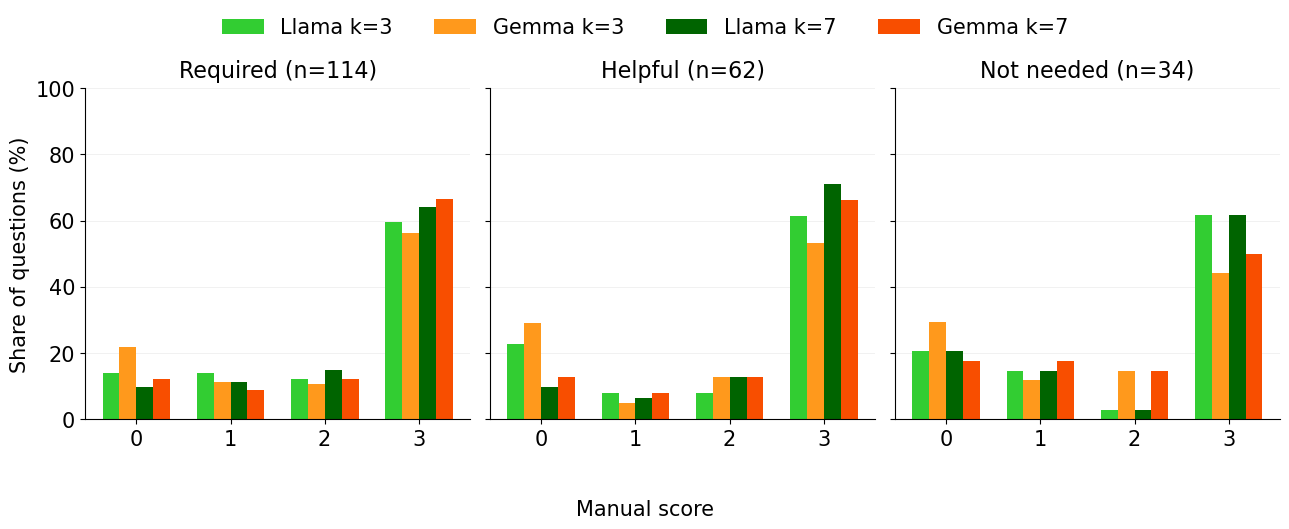

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

initial = pd.read_csv("../evaluation/eval_sheet.csv")
tuned   = pd.read_csv("../evaluation/eval_sheet_tuned.csv")

def normalize(x):
    x = str(x).strip().lower()
    if "require" in x: return "required"
    if "help"    in x: return "helpful"
    return "not needed"

initial["Retrieval Needed"] = initial["Retrieval Needed"].apply(normalize)
tuned["Retrieval Needed"]   = tuned["Retrieval Needed"].apply(normalize)

categories = ["required", "helpful", "not needed"]
scores     = [0, 1, 2, 3]

systems = {
    "Llama k=3": (initial, "Llama — Score (3/2/1/0)"),
    "Gemma k=3": (initial, "Gemma — Score (3/2/1/0)"),
    "Llama k=7": (tuned,   "Llama — Score (3/2/1/0)"),
    "Gemma k=7": (tuned,   "Gemma — Score (3/2/1/0)"),
}

# Match report diagram colors: red family for Llama, green for Gemma
colors = {
    "Gemma k=3": "#FF991C",   # warm orange
    "Gemma k=7": "#f84e00",   # deep red-orange
    "Llama k=3": "#32CD32",   # bright green
    "Llama k=7": "#006400",   # dark forest green
}

score_tables = {}
for category in categories:
    score_tables[category] = {}
    for name, (df, score_col) in systems.items():
        subset = df[df["Retrieval Needed"] == category]
        score_series = pd.to_numeric(subset[score_col], errors="coerce")
        total = len(score_series.dropna())
        counts = [(score_series == s).sum() for s in scores]
        percentages = [(c / total * 100) if total > 0 else 0 for c in counts]
        score_tables[category][name] = {
            "percentages": percentages,
            "total": total,
        }

# Taller figure, better proportions for a two-column paper
fig, axes = plt.subplots(1, 3, figsize=(13, 5), sharey=True)

bar_width = 0.18
FONTSIZE  = 15

for ax, category in zip(axes, categories):
    x = np.arange(len(scores))
    for i, name in enumerate(systems.keys()):
        percentages = score_tables[category][name]["percentages"]
        offset = (i - 1.5) * bar_width
        ax.bar(
            x + offset, percentages,
            width=bar_width, label=name,
            color=colors[name],
            edgecolor="none",
        )

    n = score_tables[category]["Llama k=3"]["total"]
    ax.set_title(
        f"{category.capitalize()} (n={n})",
        fontsize=FONTSIZE + 1, pad=8
    )
    ax.set_xticks(x)
    ax.set_xticklabels(scores, fontsize=FONTSIZE)
    ax.set_ylim(0, 100)
    ax.tick_params(axis="y", labelsize=FONTSIZE)
    ax.grid(axis="y", alpha=0.2, linewidth=0.6)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].set_ylabel("Share of questions (%)", fontsize=FONTSIZE)
fig.supxlabel("Manual score", fontsize=FONTSIZE, y=0.02)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="upper center", ncol=4,
    bbox_to_anchor=(0.5, 1.06),
    frameon=False,
    fontsize=FONTSIZE,
)

plt.tight_layout(rect=[0, 0.06, 1, 0.97])

plt.savefig(
    "../evaluation/per_category.png",
    dpi=300, bbox_inches="tight"
)
plt.savefig(
    "../evaluation/per_category.pdf",
    bbox_inches="tight"
)
plt.show()